# Tutorial 05 — Convolutional Neural Network (CNN) for CIFAR-10 Classification

## Objective

This notebook implements **Tutorial 05: Convolutional Neural Network (CNN)** using PyTorch.

The tutorial covers:

- Understanding CNNs
- Loading and preprocessing the CIFAR-10 dataset
- Visualizing image samples
- Building and training a CNN model
- Evaluating model performance
- Plotting training and validation accuracy/loss
- Making predictions on test images
- Experimenting with different CNN architectures
- Improving model accuracy
- Reducing overfitting/underfitting

The classification task is:

> Classify CIFAR-10 images into 10 object classes.


## 1. Import Required Libraries

In [1]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Folder for saved result images
os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load and Preprocess the CIFAR-10 Dataset

The CIFAR-10 dataset contains 60,000 color images.

Each image has size:

\[
32 \times 32 \times 3
\]

There are 10 classes:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

`transforms.ToTensor()` converts pixel values from `0–255` to `0–1`.


In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

basic_transform = transforms.ToTensor()

train_full_basic = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=basic_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=basic_transform
)

print("Training samples:", len(train_full_basic))
print("Test samples:", len(test_dataset))
print("Image shape:", train_full_basic[0][0].shape)
print("First label:", train_full_basic[0][1], class_names[train_full_basic[0][1]])


100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])
First label: 6 frog


## 3. Create Training and Validation Sets

The CIFAR-10 training data is split into:

- 45,000 training images
- 5,000 validation images

The test set is kept separate for final evaluation.


In [3]:
num_train = len(train_full_basic)
indices = np.arange(num_train)

np.random.seed(SEED)
np.random.shuffle(indices)

val_size = 5000
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(train_full_basic, train_indices)
val_dataset = Subset(train_full_basic, val_indices)

batch_size = 64

# num_workers=0 is safer on Windows/Jupyter
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 45000
Validation samples: 5000
Testing samples: 10000


## 4. Visualize CIFAR-10 Samples

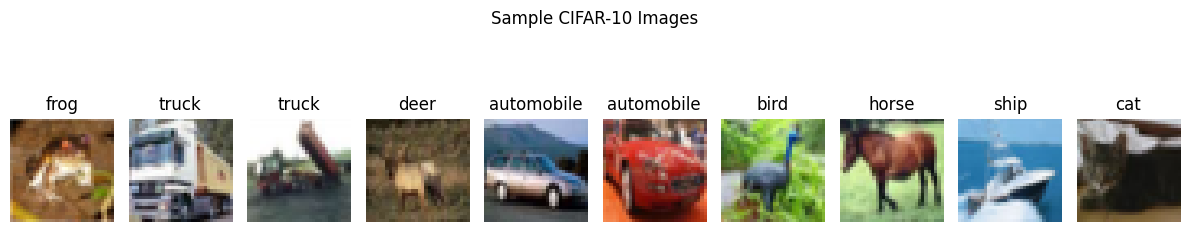

In [4]:
def show_cifar_samples(dataset, n_images=10):
    plt.figure(figsize=(12, 3))

    for i in range(n_images):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()

        plt.subplot(1, n_images, i + 1)
        plt.imshow(image_np)
        plt.title(class_names[label])
        plt.axis("off")

    plt.suptitle("Sample CIFAR-10 Images")
    plt.tight_layout()
    plt.savefig("images/tutorial_05_cifar10_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_cifar_samples(train_full_basic, n_images=10)


## 5. Define the Baseline CNN Model

The baseline CNN follows the tutorial idea:

- Convolution layer
- ReLU activation
- Max pooling
- Convolution layer
- ReLU activation
- Max pooling
- Convolution layer
- ReLU activation
- Flatten
- Fully connected layer
- Output layer

The output layer has 10 neurons because CIFAR-10 has 10 classes.


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN().to(device)
print(baseline_model)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 6. Model Summary and Trainable Parameters

In [6]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_parameter_table(model):
    rows = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            rows.append({
                "Layer": name,
                "Type": "Conv2d",
                "Input Channels": module.in_channels,
                "Output Channels": module.out_channels,
                "Kernel Size": str(module.kernel_size),
                "Parameters": module.weight.numel() + module.bias.numel()
            })
        elif isinstance(module, nn.Linear):
            rows.append({
                "Layer": name,
                "Type": "Linear",
                "Input Channels": module.in_features,
                "Output Channels": module.out_features,
                "Kernel Size": "-",
                "Parameters": module.weight.numel() + module.bias.numel()
            })

    return pd.DataFrame(rows)


baseline_param_table = model_parameter_table(baseline_model)
print("Total trainable parameters:", count_trainable_parameters(baseline_model))
baseline_param_table


Total trainable parameters: 319178


,Layer,Type,Input Channels,Output Channels,Kernel Size,Parameters
0,features.0,Conv2d,3,32,"(3, 3)",896
1,features.3,Conv2d,32,64,"(3, 3)",18496
2,features.6,Conv2d,64,64,"(3, 3)",36928
3,classifier.1,Linear,4096,64,-,262208
4,classifier.3,Linear,64,10,-,650


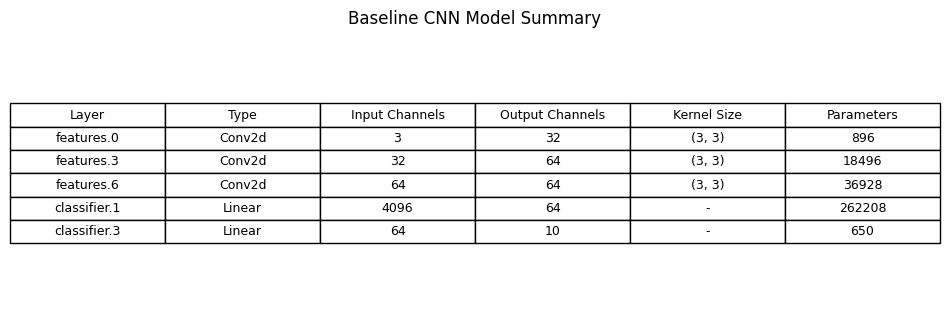

In [7]:
def save_dataframe_as_image(df, filename, title=None):
    fig_width = max(8, len(df.columns) * 2.0)
    fig_height = max(2.5, len(df) * 0.45 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


save_dataframe_as_image(
    baseline_param_table,
    "images/tutorial_05_baseline_model_summary.png",
    title="Baseline CNN Model Summary"
)


## 7. Training and Evaluation Functions

In [8]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate_one_epoch(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    weight_decay=0.0,
    early_stopping=False,
    patience=3,
    verbose=True
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("optimizer_name must be 'adam', 'sgd', or 'rmsprop'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_accuracy = evaluate_one_epoch(
            model,
            val_loader,
            criterion
        )

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["epoch_time"].append(epoch_time)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train Acc: {train_accuracy * 100:.2f}% | "
                f"Val Acc: {val_accuracy * 100:.2f}%"
            )

        if early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    total_time = time.time() - start_time

    if early_stopping:
        model.load_state_dict(best_model_state)

    return history, total_time


## 8. Train the Baseline CNN

Baseline settings:

- Optimizer: Adam
- Learning rate: 0.001
- Epochs: 10
- Batch size: 64


In [9]:
torch.manual_seed(SEED)

baseline_model = BaselineCNN().to(device)

baseline_history, baseline_time = train_model(
    baseline_model,
    train_loader,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=10,
    weight_decay=0.0,
    early_stopping=False,
    verbose=True
)

print("\nBaseline training time:", round(baseline_time, 2), "seconds")


Epoch 1/10 | Train Loss: 1.5942 | Val Loss: 1.4186 | Train Acc: 41.48% | Val Acc: 49.80%
Epoch 2/10 | Train Loss: 1.2433 | Val Loss: 1.2275 | Train Acc: 55.67% | Val Acc: 56.00%
Epoch 3/10 | Train Loss: 1.0740 | Val Loss: 1.0400 | Train Acc: 62.06% | Val Acc: 62.44%
Epoch 4/10 | Train Loss: 0.9601 | Val Loss: 0.9234 | Train Acc: 66.12% | Val Acc: 66.94%
Epoch 5/10 | Train Loss: 0.8669 | Val Loss: 0.8649 | Train Acc: 69.58% | Val Acc: 68.48%
Epoch 6/10 | Train Loss: 0.8023 | Val Loss: 0.8725 | Train Acc: 71.95% | Val Acc: 69.58%
Epoch 7/10 | Train Loss: 0.7335 | Val Loss: 0.7996 | Train Acc: 74.33% | Val Acc: 71.52%
Epoch 8/10 | Train Loss: 0.6912 | Val Loss: 0.7814 | Train Acc: 75.85% | Val Acc: 72.06%
Epoch 9/10 | Train Loss: 0.6394 | Val Loss: 0.7715 | Train Acc: 77.67% | Val Acc: 72.92%
Epoch 10/10 | Train Loss: 0.5994 | Val Loss: 0.7753 | Train Acc: 78.97% | Val Acc: 73.30%

Baseline training time: 91.93 seconds


## 9. Plot Training and Validation Accuracy/Loss

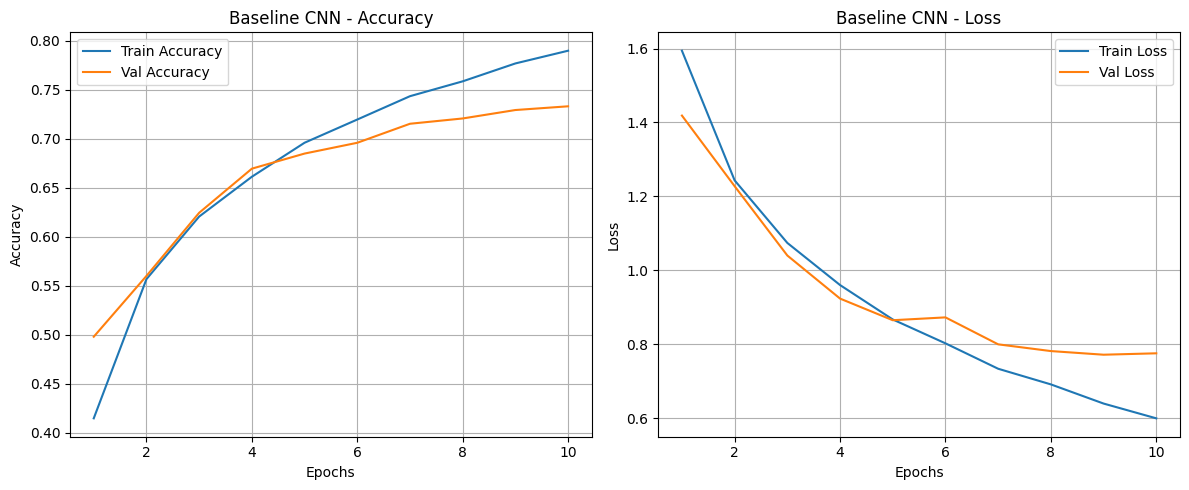

In [10]:
def plot_training_history(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_training_history(
    baseline_history,
    "Baseline CNN",
    "images/tutorial_05_baseline_training_curves.png"
)


## 10. Evaluate the Baseline Model on Test Data

In [11]:
def get_predictions(model, data_loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_predictions)


y_true, y_pred = get_predictions(baseline_model, test_loader)

baseline_test_accuracy = accuracy_score(y_true, y_pred)

print("Baseline Test Accuracy:", round(baseline_test_accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Baseline Test Accuracy: 73.32 %

Confusion Matrix:
[[761  24  31  25  34   9  14  16  48  38]
 [ 15 883   4   9   2   2  14   4  16  51]
 [ 61   4 535  61 157  53  88  29   7   5]
 [ 18  13  48 543 115 131  84  28   8  12]
 [ 12   4  29  38 823   9  48  32   4   1]
 [  5   4  47 191  97 569  37  41   7   2]
 [  5   3  27  35  50   5 867   4   3   1]
 [  9   4  28  28 129  50  10 736   2   4]
 [ 48  40   6  18  14   6  13   4 829  22]
 [ 21  93   7  23  17   7  12  13  21 786]]

Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.76      0.78      1000
  automobile       0.82      0.88      0.85      1000
        bird       0.70      0.54      0.61      1000
         cat       0.56      0.54      0.55      1000
        deer       0.57      0.82      0.68      1000
         dog       0.68      0.57      0.62      1000
        frog       0.73      0.87      0.79      1000
       horse       0.81      0.74      0.77      1000
       

## 11. Visualize Predictions on Test Images

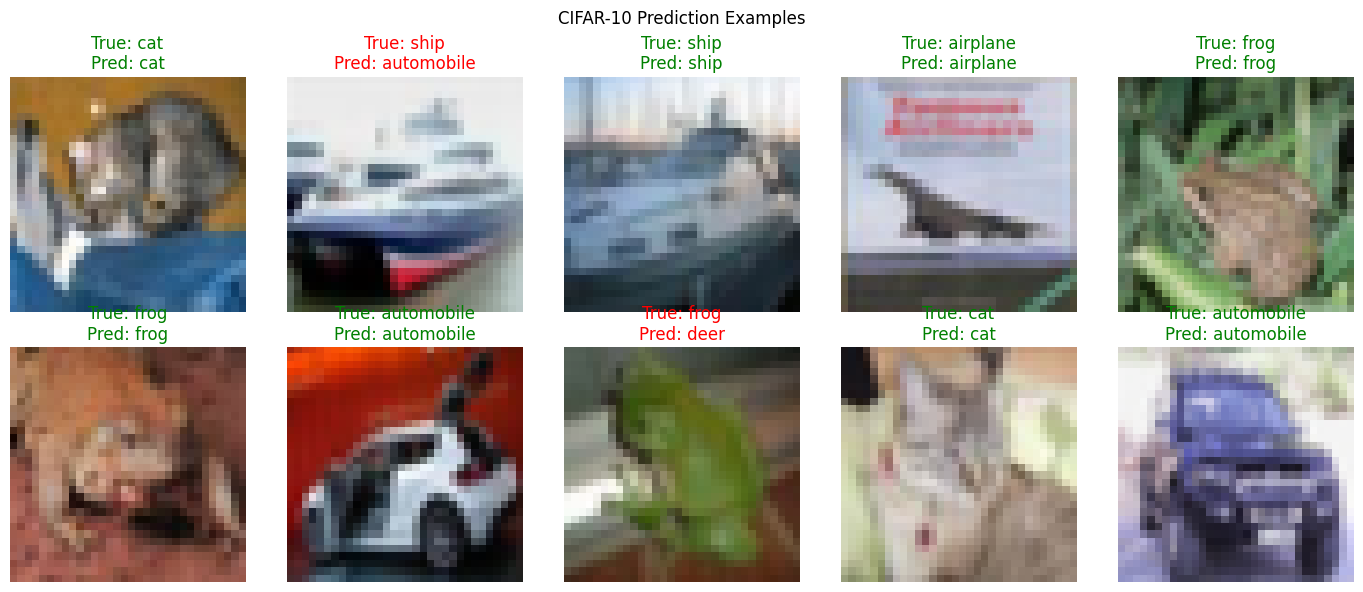

In [12]:
def visualize_predictions(model, dataset, n_images=10, filename="images/tutorial_05_prediction_examples.png"):
    model.eval()

    plt.figure(figsize=(14, 6))

    for i in range(n_images):
        image, true_label = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            _, predicted_label = torch.max(output, 1)

        color = "green" if predicted_label.item() == true_label else "red"

        plt.subplot(2, 5, i + 1)
        plt.imshow(image.permute(1, 2, 0).numpy())
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[predicted_label.item()]}",
            color=color
        )
        plt.axis("off")

    plt.suptitle("CIFAR-10 Prediction Examples")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_predictions(baseline_model, test_dataset)


# Task 1 — Experiment with Different CNN Architectures

The tutorial asks to modify the architecture by:

- Changing filter size
- Adding more convolution layers
- Changing number of filters
- Adding/changing fully connected layers
- Comparing modified models with the original model

The following CNN configurations are tested:

1. Baseline CNN
2. Larger filters
3. More filters
4. Deeper CNN
5. Larger fully connected layer


In [13]:
class FlexibleCNN(nn.Module):
    def __init__(
        self,
        conv_channels=[32, 64, 64],
        kernel_size=3,
        fc_layers=[64],
        dropout_rate=0.0,
        use_batch_norm=False
    ):
        super().__init__()

        layers = []
        in_channels = 3

        for out_channels in conv_channels:
            padding = kernel_size // 2

            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding))

            if use_batch_norm:
                layers.append(nn.BatchNorm2d(out_channels))

            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Find flattened feature size automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            feature_output = self.features(dummy)
            flatten_size = feature_output.view(1, -1).shape[1]

        classifier_layers = []
        input_size = flatten_size

        for fc_size in fc_layers:
            classifier_layers.append(nn.Linear(input_size, fc_size))
            classifier_layers.append(nn.ReLU())

            if dropout_rate > 0:
                classifier_layers.append(nn.Dropout(dropout_rate))

            input_size = fc_size

        classifier_layers.append(nn.Linear(input_size, 10))

        self.classifier = nn.Sequential(*classifier_layers)

        self.conv_channels = conv_channels
        self.kernel_size = kernel_size
        self.fc_layers = fc_layers
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


In [14]:
architecture_configs = [
    {
        "Name": "Baseline",
        "Conv Channels": [32, 64, 64],
        "Kernel Size": 3,
        "FC Layers": [64],
        "Dropout": 0.0,
        "Batch Norm": False
    },
    {
        "Name": "Larger_Kernel",
        "Conv Channels": [32, 64, 64],
        "Kernel Size": 5,
        "FC Layers": [64],
        "Dropout": 0.0,
        "Batch Norm": False
    },
    {
        "Name": "More_Filters",
        "Conv Channels": [64, 128, 128],
        "Kernel Size": 3,
        "FC Layers": [128],
        "Dropout": 0.0,
        "Batch Norm": False
    },
    {
        "Name": "Deeper_CNN",
        "Conv Channels": [32, 64, 128, 128],
        "Kernel Size": 3,
        "FC Layers": [128],
        "Dropout": 0.0,
        "Batch Norm": False
    },
    {
        "Name": "Larger_FC",
        "Conv Channels": [32, 64, 64],
        "Kernel Size": 3,
        "FC Layers": [256, 128],
        "Dropout": 0.0,
        "Batch Norm": False
    }
]

architecture_results = []
architecture_histories = {}

for config in architecture_configs:
    print("\nTraining:", config["Name"])

    torch.manual_seed(SEED)

    model = FlexibleCNN(
        conv_channels=config["Conv Channels"],
        kernel_size=config["Kernel Size"],
        fc_layers=config["FC Layers"],
        dropout_rate=config["Dropout"],
        use_batch_norm=config["Batch Norm"]
    ).to(device)

    history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        optimizer_name="adam",
        learning_rate=0.001,
        epochs=5,
        weight_decay=0.0,
        early_stopping=False,
        verbose=False
    )

    y_true_arch, y_pred_arch = get_predictions(model, test_loader)
    test_accuracy = accuracy_score(y_true_arch, y_pred_arch)

    architecture_results.append({
        "Model": config["Name"],
        "Conv Channels": str(config["Conv Channels"]),
        "Kernel Size": config["Kernel Size"],
        "FC Layers": str(config["FC Layers"]),
        "Final Train Acc": history["train_accuracy"][-1],
        "Final Val Acc": history["val_accuracy"][-1],
        "Final Train Loss": history["train_loss"][-1],
        "Final Val Loss": history["val_loss"][-1],
        "Test Accuracy": test_accuracy,
        "Training Time (s)": training_time
    })

    architecture_histories[config["Name"]] = history

architecture_results_df = pd.DataFrame(architecture_results)
architecture_results_df



Training: Baseline

Training: Larger_Kernel

Training: More_Filters

Training: Deeper_CNN

Training: Larger_FC


,Model,Conv Channels,Kernel Size,FC Layers,Final Train Acc,Final Val Acc,Final Train Loss,Final Val Loss,Test Accuracy,Training Time (s)
0,Baseline,"[32, 64, 64]",3,[64],0.684178,0.6764,0.900856,0.915705,0.6749,44.818252
1,Larger_Kernel,"[32, 64, 64]",5,[64],0.706378,0.6800,0.833626,0.890802,0.6815,49.562152
2,More_Filters,"[64, 128, 128]",3,[128],0.749733,0.7216,0.708153,0.786942,0.7255,66.998628
3,Deeper_CNN,"[32, 64, 128, 128]",3,[128],0.743378,0.7166,0.730720,0.806599,0.7152,45.413881
4,Larger_FC,"[32, 64, 64]",3,"[256, 128]",0.707756,0.6952,0.832461,0.884294,0.6839,65.871438


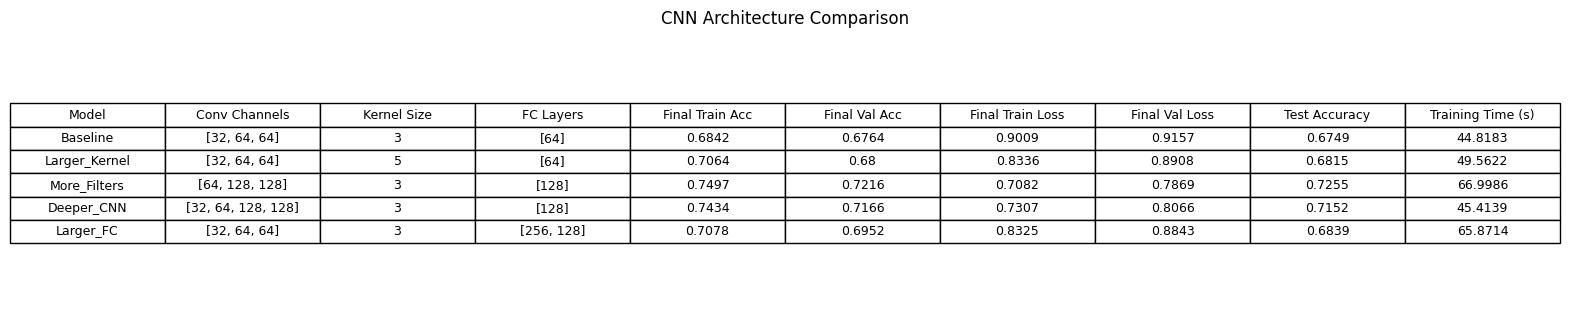

In [15]:
architecture_results_image_df = architecture_results_df.copy()

for column in [
    "Final Train Acc",
    "Final Val Acc",
    "Final Train Loss",
    "Final Val Loss",
    "Test Accuracy",
    "Training Time (s)"
]:
    architecture_results_image_df[column] = architecture_results_image_df[column].round(4)

save_dataframe_as_image(
    architecture_results_image_df,
    "images/tutorial_05_architecture_results_table.png",
    title="CNN Architecture Comparison"
)


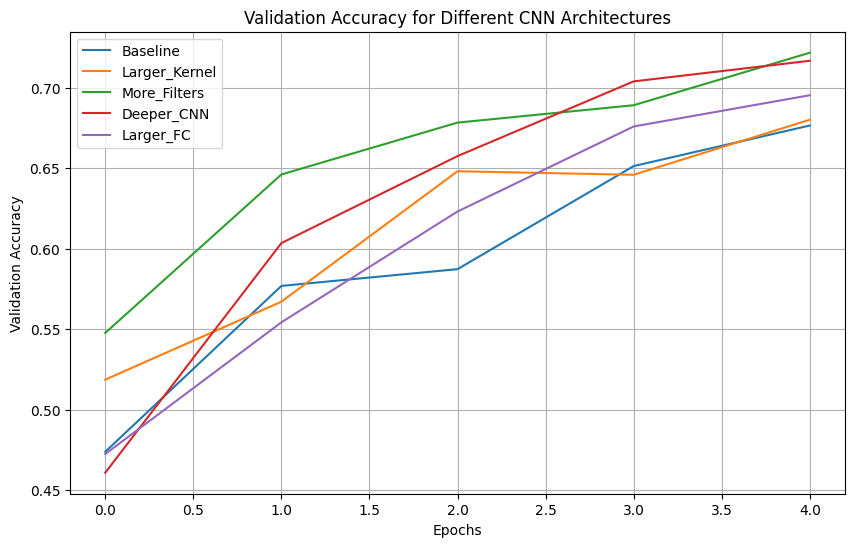

In [16]:
plt.figure(figsize=(10, 6))

for model_name, history in architecture_histories.items():
    plt.plot(history["val_accuracy"], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different CNN Architectures")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_05_architecture_accuracy_curves.png", dpi=300, bbox_inches="tight")
plt.show()


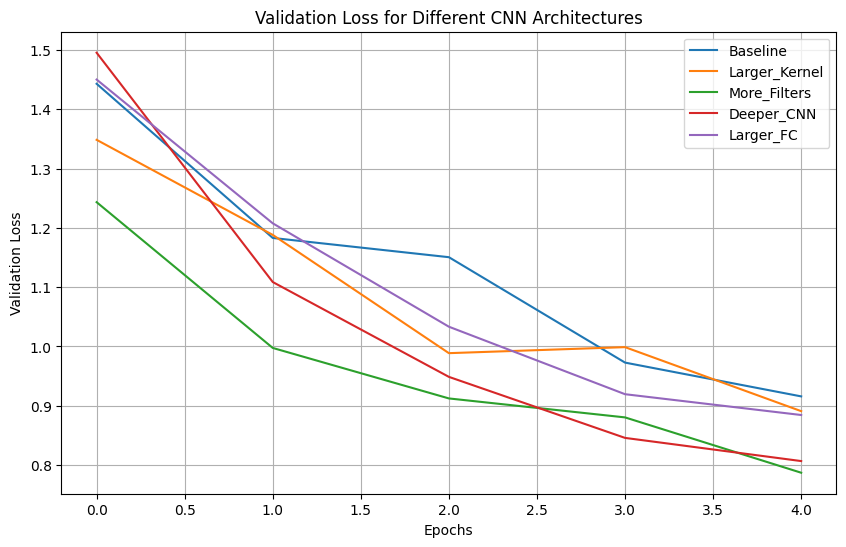

In [17]:
plt.figure(figsize=(10, 6))

for model_name, history in architecture_histories.items():
    plt.plot(history["val_loss"], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different CNN Architectures")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_05_architecture_loss_curves.png", dpi=300, bbox_inches="tight")
plt.show()


# Task 2 — Improve Accuracy and Reduce Overfitting/Underfitting

To improve accuracy and reduce overfitting/underfitting, this notebook uses:

- Data augmentation
- Batch normalization
- Dropout
- Weight decay
- Early stopping

Data augmentation improves generalization by training the model on transformed versions of images.


In [18]:
augmentation_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_full_augmented = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=augmentation_transform
)

train_dataset_augmented = Subset(train_full_augmented, train_indices)

train_loader_augmented = DataLoader(
    train_dataset_augmented,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Augmented training dataset prepared.")


Files already downloaded and verified
Augmented training dataset prepared.


Epoch 1/20 | Train Loss: 1.6526 | Val Loss: 1.2945 | Train Acc: 38.48% | Val Acc: 53.34%
Epoch 2/20 | Train Loss: 1.3322 | Val Loss: 1.1118 | Train Acc: 52.29% | Val Acc: 59.34%
Epoch 3/20 | Train Loss: 1.1785 | Val Loss: 1.0757 | Train Acc: 58.53% | Val Acc: 61.72%
Epoch 4/20 | Train Loss: 1.0900 | Val Loss: 0.9008 | Train Acc: 61.94% | Val Acc: 66.90%
Epoch 5/20 | Train Loss: 1.0149 | Val Loss: 0.9326 | Train Acc: 65.08% | Val Acc: 67.00%
Epoch 6/20 | Train Loss: 0.9555 | Val Loss: 1.1913 | Train Acc: 67.09% | Val Acc: 59.38%
Epoch 7/20 | Train Loss: 0.9091 | Val Loss: 0.7947 | Train Acc: 69.16% | Val Acc: 72.98%
Epoch 8/20 | Train Loss: 0.8634 | Val Loss: 0.7637 | Train Acc: 70.55% | Val Acc: 72.70%
Epoch 9/20 | Train Loss: 0.8259 | Val Loss: 1.0619 | Train Acc: 71.96% | Val Acc: 63.08%
Epoch 10/20 | Train Loss: 0.7916 | Val Loss: 0.8045 | Train Acc: 73.28% | Val Acc: 72.56%
Epoch 11/20 | Train Loss: 0.7587 | Val Loss: 0.6874 | Train Acc: 74.50% | Val Acc: 76.16%
Epoch 12/20 | Train

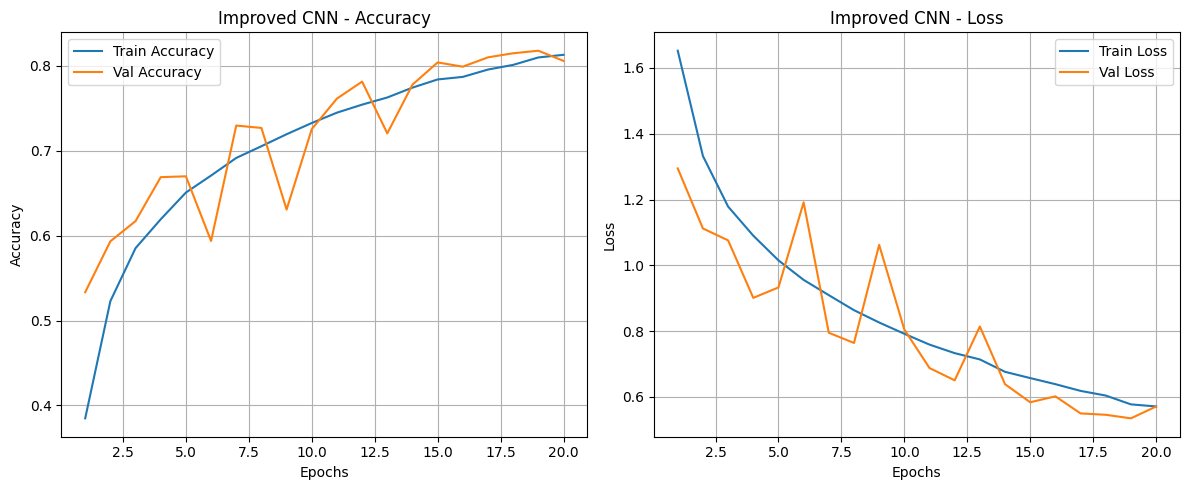

Improved Model Test Accuracy: 81.33 %
Improved training time: 399.25 seconds
Epochs trained: 20


In [19]:
torch.manual_seed(SEED)

improved_model = FlexibleCNN(
    conv_channels=[64, 128, 256],
    kernel_size=3,
    fc_layers=[256, 128],
    dropout_rate=0.4,
    use_batch_norm=True
).to(device)

improved_history, improved_time = train_model(
    improved_model,
    train_loader_augmented,
    val_loader,
    optimizer_name="adam",
    learning_rate=0.001,
    epochs=20,
    weight_decay=1e-4,
    early_stopping=True,
    patience=4,
    verbose=True
)

plot_training_history(
    improved_history,
    "Improved CNN",
    "images/tutorial_05_improved_training_curves.png"
)

y_true_improved, y_pred_improved = get_predictions(improved_model, test_loader)
improved_test_accuracy = accuracy_score(y_true_improved, y_pred_improved)

print("Improved Model Test Accuracy:", round(improved_test_accuracy * 100, 2), "%")
print("Improved training time:", round(improved_time, 2), "seconds")
print("Epochs trained:", len(improved_history["train_loss"]))


## 12. Compare Baseline and Improved Model

In [20]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        "Regularization": "None",
        "Data Augmentation": "No",
        "Final Train Acc": baseline_history["train_accuracy"][-1],
        "Final Val Acc": baseline_history["val_accuracy"][-1],
        "Test Accuracy": baseline_test_accuracy,
        "Epochs Trained": len(baseline_history["train_loss"])
    },
    {
        "Model": "Improved CNN",
        "Regularization": "BatchNorm + Dropout + Weight Decay + Early Stopping",
        "Data Augmentation": "Yes",
        "Final Train Acc": improved_history["train_accuracy"][-1],
        "Final Val Acc": improved_history["val_accuracy"][-1],
        "Test Accuracy": improved_test_accuracy,
        "Epochs Trained": len(improved_history["train_loss"])
    }
])

comparison_image_df = comparison_df.copy()

for column in ["Final Train Acc", "Final Val Acc", "Test Accuracy"]:
    comparison_image_df[column] = comparison_image_df[column].round(4)

comparison_df


,Model,Regularization,Data Augmentation,Final Train Acc,Final Val Acc,Test Accuracy,Epochs Trained
0,Baseline CNN,None,No,0.789689,0.733,0.7332,10
1,Improved CNN,BatchNorm + Dropout + Weight Decay + Early Sto...,Yes,0.813156,0.806,0.8133,20


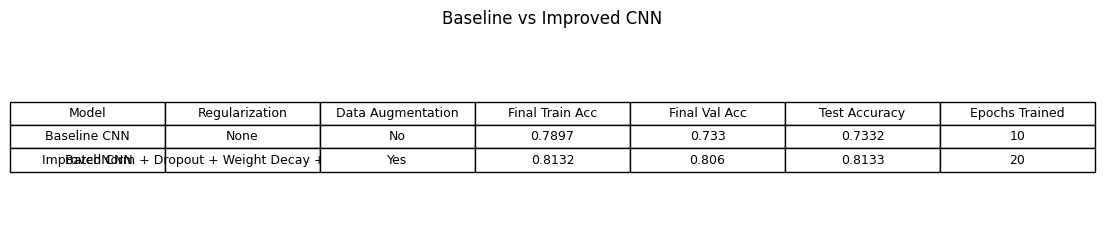

In [21]:
save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_05_baseline_vs_improved_table.png",
    title="Baseline vs Improved CNN"
)


## 13. Visualize Improved Model Predictions

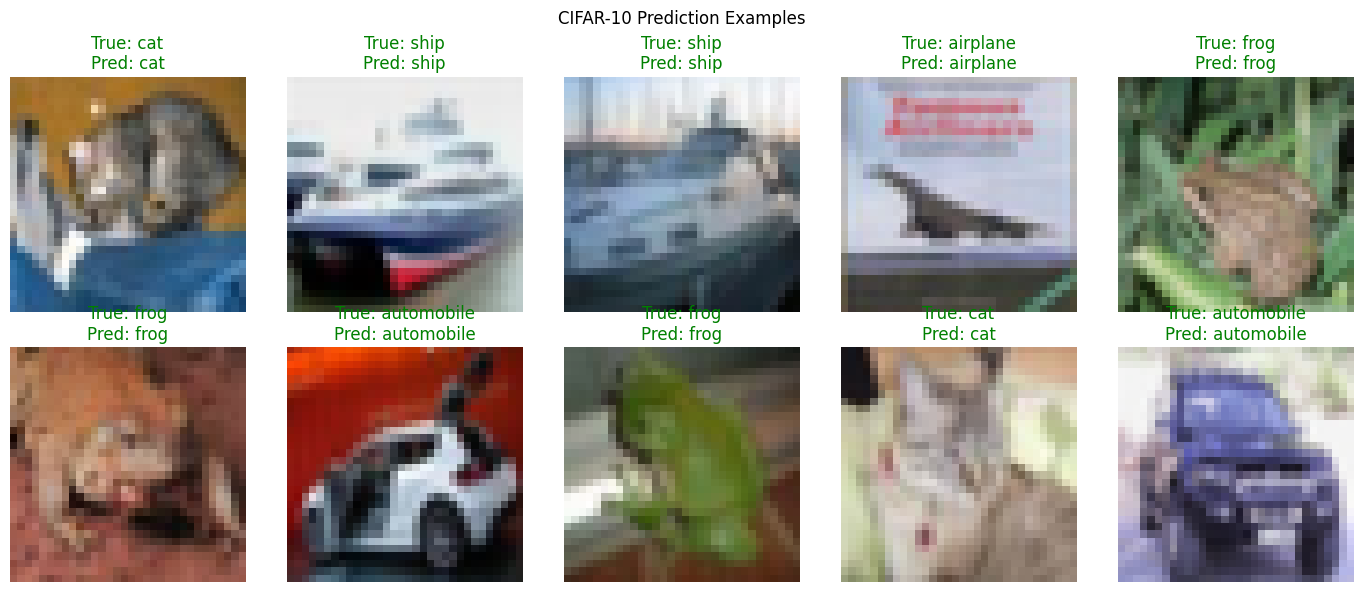

In [22]:
visualize_predictions(
    improved_model,
    test_dataset,
    n_images=10,
    filename="images/tutorial_05_improved_prediction_examples.png"
)


# Final Observations

## Baseline CNN

The baseline CNN learns spatial features using convolution and pooling layers.  
The training and validation curves help identify whether the model is learning well, overfitting, or underfitting.

## Architecture Experiments

Changing the number of filters, kernel size, convolution layers, and fully connected layers affects model performance.  
A larger model may learn better features, but it can also overfit if regularization is not used.

## Improved CNN

The improved model uses data augmentation, batch normalization, dropout, weight decay, and early stopping.  
These techniques help improve generalization and reduce overfitting.

## Key Learning

CNNs are more suitable for image data than fully connected networks because convolutional layers preserve spatial information and learn local image patterns.
